# Parcel Attention Network Embeddings

Visualize predefined Schaefer/Yeo networks from token-level attention features. The notebook compares three parcel-by-token representations: raw globally normalized token attention, mean-centered token deviation, and modality-balanced token deviation. Each representation is embedded with MDS, t-SNE, and PCA under both cosine-style and L2 distance views, with points colored by predefined network labels.


In [183]:
%matplotlib inline

from pathlib import Path
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from nilearn import datasets

from scipy.stats import rankdata
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

font_dir = "/engram/nklab/pf2477/other/font/"
if os.path.isdir(font_dir):
    for font in os.listdir(font_dir):
        if font.startswith("Times New Roman"):
            fm.fontManager.addfont(os.path.join(font_dir, font))

plt.rcParams["font.family"] = "Times New Roman"
sns.set_theme(style="whitegrid", context="paper", font="Times New Roman")

REPO_ROOT = Path.cwd()
if REPO_ROOT.name != "multimodal_encoder":
    REPO_ROOT = Path("/engram/nklab/pf2477/multimodal_encoder")

RESULT_ROOT = REPO_ROOT / "attn_map_analysis" / "results"
FIGURE_ROOT = REPO_ROOT / "attn_map_analysis" / "figures"
TABLE_ROOT = REPO_ROOT / "attn_map_analysis" / "tables"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)

RUNS = (
    (1, "04-07-2026-16-09", "dino_whisper_llama", "parcels"),
    (2, "04-07-2026-16-13", "dino_whisper_llama", "parcels"),
    (3, "04-08-2026-00-52", "dino_whisper_llama", "parcels"),
    (5, "04-08-2026-00-55", "dino_whisper_llama", "parcels"),
    (1, "04-08-2026-23-43", "dino_whisper_llama", "voxels"),
    (2, "04-08-2026-23-48", "dino_whisper_llama", "voxels"),
    (3, "04-08-2026-23-57", "dino_whisper_llama", "voxels"),
    (5, "04-12-2026-19-49", "dino_whisper_llama", "voxels"),
    (1, "04-18-2026-01-08", "videmae_wav2vec_deberta", "parcels"),
    (2, "04-18-2026-01-14", "videmae_wav2vec_deberta", "parcels"),
    (3, "04-18-2026-22-20", "videmae_wav2vec_deberta", "parcels"),
    (5, "04-18-2026-22-22", "videmae_wav2vec_deberta", "parcels"),
    (1, "04-19-2026-02-08", "videmae_wav2vec_deberta", "voxels"),
    (2, "04-19-2026-02-10", "videmae_wav2vec_deberta", "voxels"),
    (3, "04-20-2026-00-29", "videmae_wav2vec_deberta", "voxels"),
    (5, "04-20-2026-00-29", "videmae_wav2vec_deberta", "voxels"),
)

SELECTED_RUN_INDEX = 8
SELECTED_RUN_KEY = None
YEO_NETWORKS = 7

ZSCORE_TOKENS_WITHIN_MODALITY = True
TOKEN_STD_FLOOR = 1e-6
BALANCE_MODALITY_BLOCKS = True
DISTANCE_METRICS = ("cosine",)  #  "spearman", "l2", "pearson",
TSNE_PERPLEXITY = 25
RANDOM_STATE = 42
COLOR_PALETTE = {
    'Vis': '#F27970',
    'SomMot': '#BB9727',
    'DorsAttn': '#54B345',
    'SalVentAttn': '#32B897',
    'Limbic': '#05B9E2',
    'Cont': '#8983BF',
    'Default': '#C76DA2'
}


## Load Run and Schaefer Labels

In [184]:
def load_json(path):
    with Path(path).open("r") as f:
        return json.load(f)


def make_run_key(subject_id, run_name, backbones, readout):
    return f"sub-{int(subject_id):02d}_{backbones}_{readout}_{run_name}"


def file_label(run):
    return f"sub-{run['subject_id']:02d}_{run['backbones']}_{run['readout']}_{run['run_name']}"


def selected_run_spec():
    if SELECTED_RUN_KEY is not None:
        for spec in RUNS:
            subject_id, run_name, backbones, readout = spec
            if make_run_key(subject_id, run_name, backbones, readout) == SELECTED_RUN_KEY:
                return spec
        raise KeyError(f"SELECTED_RUN_KEY not found in RUNS: {SELECTED_RUN_KEY}")
    return RUNS[int(SELECTED_RUN_INDEX)]


def load_run(spec):
    subject_id, run_name, backbones, readout = spec
    if readout != "parcels":
        raise ValueError(
            "Token-level network embedding is implemented for parcel readouts only. "
            f"Selected readout={readout!r}."
        )

    run_dir = RESULT_ROOT / str(subject_id) / run_name
    if not run_dir.exists():
        raise FileNotFoundError(run_dir)

    metadata = load_json(run_dir / "metadata.json")
    qc = load_json(run_dir / "quality_control.json")
    modalities = list(metadata["modalities"])
    query_to_parcel = np.load(run_dir / "query_to_parcel.npy").astype(int)

    mean_path = run_dir / "parcel_token_attn_mean.npy"
    fraction_path = run_dir / "parcel_token_attn_fraction.npy"
    if not mean_path.exists() or not fraction_path.exists():
        raise FileNotFoundError(
            f"Missing token-level attention for {run_dir}. Expected both "
            "parcel_token_attn_mean.npy and parcel_token_attn_fraction.npy. "
            "Re-run the atlas exporter with --save-token-level."
        )

    token_mean = np.load(mean_path).astype(np.float64)
    token_fraction = np.load(fraction_path).astype(np.float64)
    token_fraction = token_fraction / np.clip(token_fraction.sum(axis=1, keepdims=True), 1e-12, None)

    token_metadata_path = run_dir / "token_metadata.csv"
    if not token_metadata_path.exists():
        raise FileNotFoundError(token_metadata_path)
    token_metadata = pd.read_csv(token_metadata_path)

    expected_shape = (query_to_parcel.shape[0], int(metadata["num_memory_tokens"]))
    for name, array in {"token_mean": token_mean, "token_fraction": token_fraction}.items():
        if array.shape != expected_shape:
            raise ValueError(f"Expected {name} shape {expected_shape}, got {array.shape}")
    if len(token_metadata) != token_mean.shape[1]:
        raise ValueError(f"Expected {token_mean.shape[1]} token metadata rows, got {len(token_metadata)}")
    if sorted(token_metadata["modality"].unique().tolist()) != sorted(modalities):
        raise ValueError("Token metadata modalities do not match run metadata modalities.")

    return {
        "run_key": make_run_key(subject_id, run_name, backbones, readout),
        "subject_id": int(subject_id),
        "run_name": str(run_name),
        "backbones": str(backbones),
        "readout": str(readout),
        "run_dir": run_dir,
        "metadata": metadata,
        "qc": qc,
        "modalities": modalities,
        "query_to_parcel": query_to_parcel,
        "token_mean": token_mean,
        "token_fraction": token_fraction,
        "token_metadata": token_metadata,
    }


def as_str(label):
    return label.decode("utf-8") if isinstance(label, bytes) else str(label)


def parse_schaefer_label(label):
    label = as_str(label)
    parts = label.split("_")
    return {
        "schaefer_name": label,
        "hemi": parts[1],
        "network": parts[2],
        "region": "_".join(parts[3:-1]),
        "parcel_index_in_lut": int(parts[-1]),
    }


def load_schaefer_labels(n_rois=1000, yeo_networks=17, resolution_mm=2):
    atlas = datasets.fetch_atlas_schaefer_2018(
        n_rois=n_rois,
        yeo_networks=yeo_networks,
        resolution_mm=resolution_mm,
    )
    raw_labels = [as_str(label) for label in atlas.labels if as_str(label) != "Background"]

    network_order = []
    rows = []
    for parcel_id, label in enumerate(raw_labels, start=1):
        parsed = parse_schaefer_label(label)
        if parsed["network"] not in network_order:
            network_order.append(parsed["network"])
        rows.append({"parcel_id": parcel_id, **parsed})

    return pd.DataFrame(rows), network_order


run = load_run(selected_run_spec())
labels_df, schaefer_labels = load_schaefer_labels(yeo_networks=YEO_NETWORKS)
run["run_key"], run["token_mean"].shape, schaefer_labels



[fetch_atlas_schaefer_2018] Dataset found in /home/pf2477/nilearn_data/schaefer_2018


('sub-01_videmae_wav2vec_deberta_parcels_04-18-2026-01-08',
 (1000, 3619),
 ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default'])

## Feature Representations

In [185]:
def l2_normalize_rows(values, eps=1e-12):
    return values / np.clip(np.linalg.norm(values, axis=1, keepdims=True), eps, None)


def pairwise_l2_distance(values):
    sq_norm = np.sum(values ** 2, axis=1, keepdims=True)
    sq_dist = sq_norm + sq_norm.T - 2.0 * values @ values.T
    dist = np.sqrt(np.clip(sq_dist, 0.0, None))
    dist = (dist + dist.T) / 2.0
    np.fill_diagonal(dist, 0.0)
    return dist


def pairwise_cosine_distance(values):
    row_normed = l2_normalize_rows(values)
    sim = cosine_similarity(row_normed)
    sim = np.clip((sim + sim.T) / 2.0, -1.0, 1.0)
    np.fill_diagonal(sim, 1.0)
    dist = np.clip(1.0 - sim, 0.0, 2.0)
    dist = (dist + dist.T) / 2.0
    np.fill_diagonal(dist, 0.0)
    return dist


def row_rank_transform(values):
    ranks = np.apply_along_axis(rankdata, 1, np.asarray(values, dtype=np.float64), method="average")
    return ranks - ranks.mean(axis=1, keepdims=True)


def pairwise_correlation_distance(values):
    dist = pairwise_distances(np.asarray(values, dtype=np.float64), metric="correlation")
    dist = np.nan_to_num(dist, nan=0.0, posinf=2.0, neginf=0.0)
    dist = np.clip((dist + dist.T) / 2.0, 0.0, 2.0)
    np.fill_diagonal(dist, 0.0)
    return dist


def pairwise_spearman_distance(values):
    return pairwise_correlation_distance(row_rank_transform(values))


def distance_for_metric(values, metric):
    if metric == "cosine":
        return pairwise_cosine_distance(values)
    if metric == "l2":
        return pairwise_l2_distance(values)
    if metric == "pearson":
        return pairwise_correlation_distance(values)
    if metric == "spearman":
        return pairwise_spearman_distance(values)
    raise ValueError(f"Unknown metric: {metric}")


def features_for_pca(values, metric):
    if metric == "cosine":
        return l2_normalize_rows(values)
    if metric == "l2":
        return values
    if metric == "pearson":
        return np.asarray(values, dtype=np.float64) - np.asarray(values, dtype=np.float64).mean(axis=1, keepdims=True)
    if metric == "spearman":
        return row_rank_transform(values)
    raise ValueError(f"Unknown metric: {metric}")


def modality_balanced_deviation_features(
    token_fraction,
    token_metadata,
    modalities,
    zscore_tokens=True,
    token_std_floor=1e-6,
    balance_modality_blocks=True,
):
    blocks = []
    block_records = []
    modality_values = token_metadata["modality"].astype(str).to_numpy()

    for modality in modalities:
        token_idx = np.flatnonzero(modality_values == modality)
        if token_idx.size == 0:
            raise ValueError(f"No token metadata rows found for modality={modality!r}")

        block = token_fraction[:, token_idx]
        block_mean = block.mean(axis=0, keepdims=True)
        block_dev = block - block_mean

        if zscore_tokens:
            block_std = block.std(axis=0, keepdims=True)
            block_dev = block_dev / np.clip(block_std, token_std_floor, None)
        else:
            block_std = np.full((1, token_idx.size), np.nan, dtype=np.float64)

        if balance_modality_blocks:
            block_dev = block_dev / np.sqrt(float(token_idx.size))

        blocks.append(block_dev)
        block_records.append({
            "representation": "modality_balanced_token_deviation",
            "modality": modality,
            "n_tokens": int(token_idx.size),
            "mean_token_fraction": float(block.mean()),
            "mean_abs_deviation": float(np.abs(block - block_mean).mean()),
            "median_token_std": float(np.median(block_std)) if zscore_tokens else np.nan,
            "zscore_tokens": bool(zscore_tokens),
            "balanced_by_sqrt_token_count": bool(balance_modality_blocks),
        })

    return np.concatenate(blocks, axis=1), pd.DataFrame(block_records)


def modality_fraction_features(token_fraction, token_metadata, modalities):
    modality_values = token_metadata["modality"].astype(str).to_numpy()
    columns = []
    records = []
    for modality in modalities:
        token_idx = np.flatnonzero(modality_values == modality)
        if token_idx.size == 0:
            raise ValueError(f"No token metadata rows found for modality={modality!r}")
        values = token_fraction[:, token_idx].sum(axis=1)
        columns.append(values)
        records.append({
            "modality": modality,
            "n_tokens": int(token_idx.size),
            "mean_modality_fraction": float(values.mean()),
            "std_modality_fraction": float(values.std(ddof=1)),
        })
    modality_fraction = np.stack(columns, axis=1)
    modality_centered = modality_fraction - modality_fraction.mean(axis=0, keepdims=True)
    return modality_fraction, modality_centered, pd.DataFrame(records)


def build_feature_representations(run):
    raw_global = run["token_mean"].astype(np.float64)
    raw_global = raw_global / np.clip(raw_global.sum(), 1e-12, None)

    centered = raw_global - raw_global.mean(axis=0, keepdims=True)
    modality_fraction, modality_centered, modality_fraction_df = modality_fraction_features(
        run["token_fraction"],
        run["token_metadata"],
        run["modalities"],
    )
    modality_balanced, block_balance_df = modality_balanced_deviation_features(
        run["token_fraction"],
        run["token_metadata"],
        run["modalities"],
        zscore_tokens=ZSCORE_TOKENS_WITHIN_MODALITY,
        token_std_floor=TOKEN_STD_FLOOR,
        balance_modality_blocks=BALANCE_MODALITY_BLOCKS,
    )

    representations = {
        # "raw_global_token_attention": {
        #     "label": "Raw global token attention",
        #     "features": raw_global,
        #     "description": "parcel_token_attn_mean divided by the global matrix sum",
        # },
        # "mean_centered_token_deviation": {
        #     "label": "Mean-centered token deviation",
        #     "features": centered,
        #     "description": "raw global token attention minus the across-parcel mean for each token",
        # },
        # "modality_centered_token_attention": {
        #     "label": "Modality-centered token attention",
        #     "features": modality_centered,
        #     "description": "parcel-by-modality token attention [Q, M] from per-parcel token fractions, centered across parcels",
        #     "modality_fraction": modality_fraction,
        # },
        "modality_balanced_token_deviation": {
            "label": "Modality-balanced token deviation",
            "features": modality_balanced,
            "description": "within-modality centered token deviations, optionally z-scored and block-balanced",
        },
    }
    return representations, block_balance_df, modality_fraction_df


representations, block_balance_df, modality_fraction_df = build_feature_representations(run)
base_parcel_df = pd.DataFrame({
    "run_key": run["run_key"],
    "subject_id": run["subject_id"],
    "run_name": run["run_name"],
    "backbones": run["backbones"],
    "readout": run["readout"],
    "parcel_id": run["query_to_parcel"],
    "token_fraction_row_sum": run["token_fraction"].sum(axis=1),
})
base_parcel_df = base_parcel_df.merge(labels_df, on="parcel_id", how="left")
missing_network = int(base_parcel_df["network"].isna().sum())
if missing_network:
    raise ValueError(f"Missing Schaefer labels for {missing_network} parcels")

feature_summary_records = []
for representation_name, spec in representations.items():
    features = spec["features"]
    feature_summary_records.append({
        "run_key": run["run_key"],
        "representation": representation_name,
        "label": spec["label"],
        "description": spec["description"],
        "n_parcels": int(features.shape[0]),
        "n_features": int(features.shape[1]),
        "feature_mean": float(features.mean()),
        "feature_std": float(features.std()),
        "mean_row_l2_norm": float(np.linalg.norm(features, axis=1).mean()),
        "zscore_tokens_within_modality": ZSCORE_TOKENS_WITHIN_MODALITY,
        "balance_modality_blocks": BALANCE_MODALITY_BLOCKS,
    })
    np.save(
        TABLE_ROOT / f"{file_label(run)}_{representation_name}_feature_matrix.npy",
        features.astype(np.float32),
    )

feature_summary_df = pd.DataFrame(feature_summary_records)
feature_summary_df.to_csv(TABLE_ROOT / f"{file_label(run)}_token_feature_representation_summary.csv", index=False)
block_balance_df.to_csv(TABLE_ROOT / f"{file_label(run)}_modality_balanced_token_deviation_block_balance.csv", index=False)
modality_fraction_df.to_csv(TABLE_ROOT / f"{file_label(run)}_modality_centered_token_attention_summary.csv", index=False)
feature_summary_df


,run_key,representation,label,description,n_parcels,n_features,feature_mean,feature_std,mean_row_l2_norm,zscore_tokens_within_modality,balance_modality_blocks
0,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,modality_balanced_token_deviation,Modality-balanced token deviation,"within-modality centered token deviations, opt...",1000,3619,3.877651e-20,0.028792,1.655773,True,True


## MDS, t-SNE, and PCA Embeddings

In [186]:
def make_mds(random_state=42):
    kwargs = {
        "n_components": 2,
        "dissimilarity": "precomputed",
        "random_state": random_state,
    }
    try:
        return MDS(**kwargs, normalized_stress="auto")
    except TypeError:
        return MDS(**kwargs)


def make_tsne(distance, random_state=42):
    n_samples = int(distance.shape[0])
    perplexity = min(float(TSNE_PERPLEXITY), max(5.0, (n_samples - 1) / 3.0))
    kwargs = {
        "n_components": 2,
        "metric": "precomputed",
        "init": "random",
        "perplexity": perplexity,
        "random_state": random_state,
    }
    try:
        return TSNE(**kwargs, learning_rate="auto")
    except TypeError:
        return TSNE(**kwargs)


embedding_frames = []
pca_summary_records = []
for rep_idx, (representation_name, spec) in enumerate(representations.items()):
    features = spec["features"]
    for metric_idx, metric in enumerate(DISTANCE_METRICS):
        distance = distance_for_metric(features, metric)
        pd.DataFrame(distance).to_csv(
            TABLE_ROOT / f"{file_label(run)}_{representation_name}_{metric}_distance.csv",
            index=False,
        )

        seed = RANDOM_STATE # + 100 * rep_idx + metric_idx
        # mds_embedding = make_mds(random_state=seed).fit_transform(distance)
        tsne_embedding = make_tsne(distance, random_state=seed).fit_transform(distance)

        # pca_input = features_for_pca(features, metric)
        # pca_model = PCA(n_components=2, random_state=seed)
        # pca_embedding = pca_model.fit_transform(pca_input)
        # pca_summary_records.extend([
        #     {
        #         "run_key": run["run_key"],
        #         "representation": representation_name,
        #         "metric_view": metric,
        #         "component": "PC1",
        #         "explained_variance_ratio": float(pca_model.explained_variance_ratio_[0]),
        #     },
        #     {
        #         "run_key": run["run_key"],
        #         "representation": representation_name,
        #         "metric_view": metric,
        #         "component": "PC2",
        #         "explained_variance_ratio": float(pca_model.explained_variance_ratio_[1]),
        #     },
        # ])

        frame = base_parcel_df.copy()
        frame["representation"] = representation_name
        frame["representation_label"] = spec["label"]
        frame["metric_view"] = metric
        # frame["mds1"] = mds_embedding[:, 0]
        # frame["mds2"] = mds_embedding[:, 1]
        frame["tsne1"] = tsne_embedding[:, 0]
        frame["tsne2"] = tsne_embedding[:, 1]
        # frame["pc1"] = pca_embedding[:, 0]
        # frame["pc2"] = pca_embedding[:, 1]
        embedding_frames.append(frame)

embedding_df = pd.concat(embedding_frames, ignore_index=True)
pca_summary_df = pd.DataFrame(pca_summary_records)
embedding_df.to_csv(TABLE_ROOT / f"{file_label(run)}_token_representation_network_embeddings.csv", index=False)
pca_summary_df.to_csv(TABLE_ROOT / f"{file_label(run)}_token_representation_pca_summary.csv", index=False)
pca_summary_df


""


## Network-Colored Embedding Plots

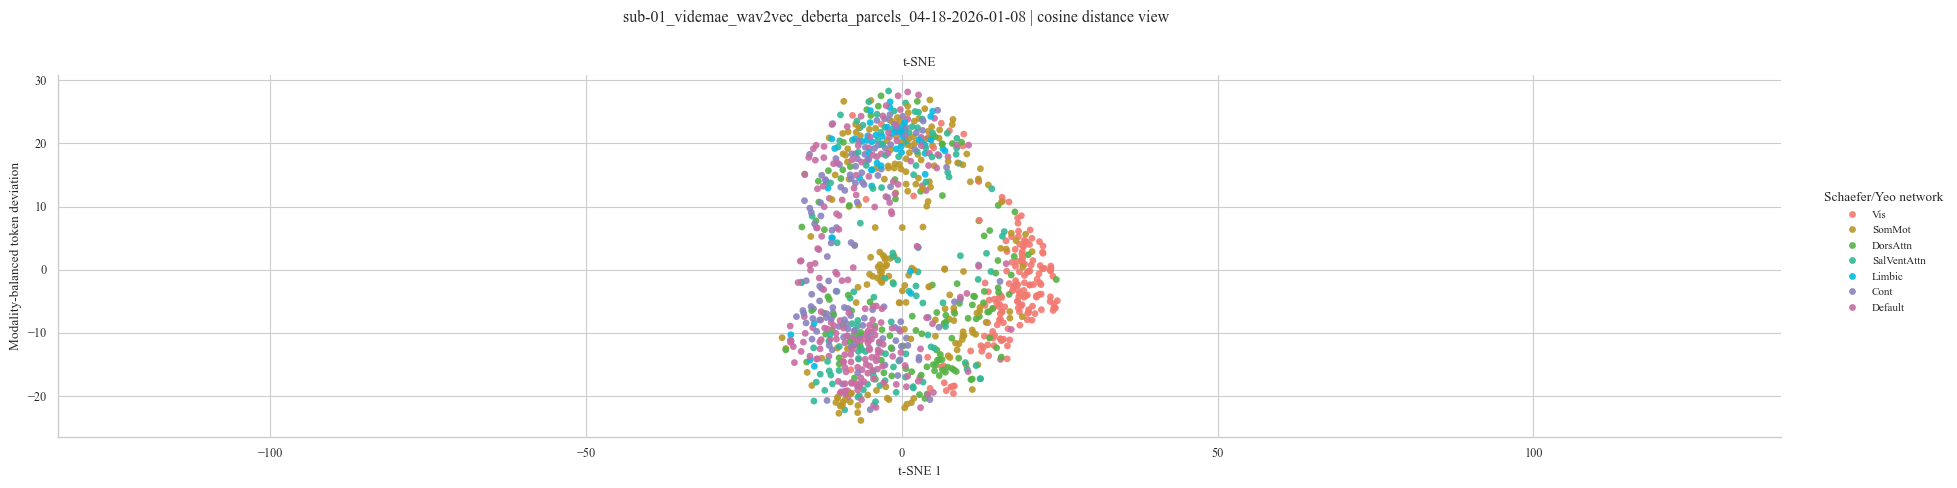

In [187]:
def plot_metric_embedding_grid(embedding_df, metric_view, out_file=None):
    plot_df = embedding_df[embedding_df["metric_view"] == metric_view].copy()
    representation_order = list(representations.keys())
    network_order = [network for network in schaefer_labels if network in set(plot_df["network"])]
    palette = [COLOR_PALETTE[network] for network in network_order]
    methods = [
        # ("mds1", "mds2", "MDS"),
        ("tsne1", "tsne2", "t-SNE"),
        # ("pc1", "pc2", "PCA"),
    ]

    fig, axes = plt.subplots(
        len(representation_order),
        len(methods),
        figsize=(18, 4.8 * len(representation_order)),
        facecolor="white",
        squeeze=False,
    )
    for row_idx, representation_name in enumerate(representation_order):
        row_df = plot_df[plot_df["representation"] == representation_name]
        row_label = representations[representation_name]["label"]
        for col_idx, (x, y, method_label) in enumerate(methods):
            ax = axes[row_idx, col_idx]
            sns.scatterplot(
                data=row_df,
                x=x,
                y=y,
                hue="network",
                hue_order=network_order,
                palette=COLOR_PALETTE,
                s=24,
                linewidth=0,
                alpha=0.9,
                ax=ax,
                legend=(row_idx == 0 and col_idx == len(methods) - 1),
            )
            if row_idx == 0:
                ax.set_title(method_label)
            if col_idx == 0:
                ax.set_ylabel(row_label)
            else:
                ax.set_ylabel("")
            ax.set_xlabel(f"{method_label} 1" if x.endswith("1") else x)
            ax.set_aspect("equal", adjustable="datalim")
            ax.grid(True)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    handles, labels = axes[0, -1].get_legend_handles_labels()
    if axes[0, -1].legend_ is not None:
        axes[0, -1].legend_.remove()
    fig.legend(
        handles,
        labels,
        title="Schaefer/Yeo network",
        bbox_to_anchor=(1.01, 0.5),
        loc="center left",
        frameon=False,
        fontsize=8,
    )
    fig.suptitle(
        f"{file_label(run)} | {metric_view} distance view",
        y=1.005,
    )
    fig.tight_layout()
    if out_file is not None:
        fig.savefig(out_file, dpi=250, bbox_inches="tight")
    return fig, axes


for metric_view in DISTANCE_METRICS:
    plot_metric_embedding_grid(
        embedding_df,
        metric_view=metric_view,
        out_file=FIGURE_ROOT / f"{file_label(run)}_token_representations_{metric_view}_mds_tsne_pca_networks.pdf",
    )
    plt.show()


## Network Centroids

In [188]:
centroid_records = []
for (representation, metric_view, network), group in embedding_df.groupby(
    ["representation", "metric_view", "network"],
    sort=False,
):
    centroid_records.append({
        "run_key": run["run_key"],
        "representation": representation,
        "metric_view": metric_view,
        "network": network,
        "n_parcels": int(len(group)),
        # "mds1_mean": float(group["mds1"].mean()),
        # "mds2_mean": float(group["mds2"].mean()),
        "tsne1_mean": float(group["tsne1"].mean()),
        "tsne2_mean": float(group["tsne2"].mean()),
        # "pc1_mean": float(group["pc1"].mean()),
        # "pc2_mean": float(group["pc2"].mean()),
    })
network_centroid_df = pd.DataFrame(centroid_records)
network_centroid_df.to_csv(TABLE_ROOT / f"{file_label(run)}_token_representation_network_embedding_centroids.csv", index=False)
network_centroid_df


,run_key,representation,metric_view,network,n_parcels,tsne1_mean,tsne2_mean
0,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,modality_balanced_token_deviation,cosine,Vis,162,16.637180,-2.514372
1,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,modality_balanced_token_deviation,cosine,SomMot,194,0.941584,3.311138
2,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,modality_balanced_token_deviation,cosine,DorsAttn,122,2.337040,-3.637542
3,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,modality_balanced_token_deviation,cosine,SalVentAttn,121,-1.490784,1.147084
4,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,modality_balanced_token_deviation,cosine,Limbic,60,-2.641262,16.831396
5,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,modality_balanced_token_deviation,cosine,Cont,129,-6.178550,2.296203
6,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,modality_balanced_token_deviation,cosine,Default,212,-5.806685,-2.067737


## Focused t-SNE Plot


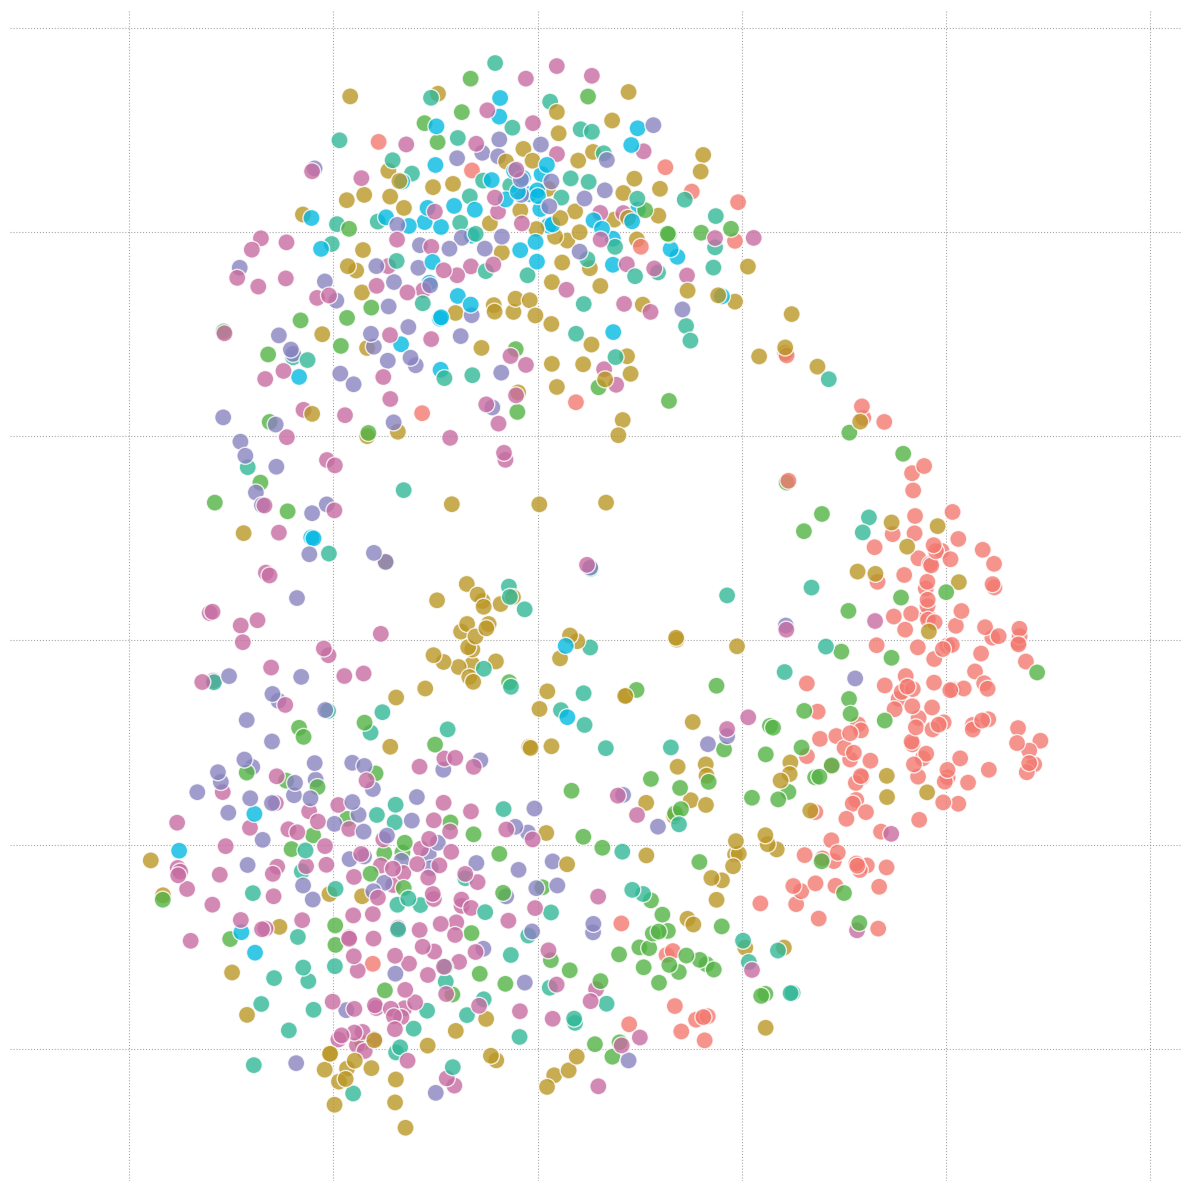

In [189]:
focused_df = embedding_df[
    (embedding_df["representation"] == "modality_balanced_token_deviation")
    & (embedding_df["metric_view"] == "cosine")
].copy()

network_order = [network for network in schaefer_labels if network in set(focused_df["network"])]
try:
    palette = [COLOR_PALETTE.get(network, None) for network in network_order]
    if any(color is None for color in palette):
        raise NameError
except NameError:
    palette = sns.color_palette("tab20", n_colors=max(20, len(network_order)))[:len(network_order)]

fig, ax = plt.subplots(figsize=(12, 12), facecolor="white")
sns.scatterplot(
    data=focused_df,
    x="tsne1",
    y="tsne2",
    hue="network",
    hue_order=network_order,
    palette=palette,
    s=150,
    linewidth=1,
    alpha=0.8,
    ax=ax,
    legend=False,
)
ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel("")
ax.set_ylabel("")
# ax.set_xticks([])
# ax.set_yticks([])
ax.grid(True, linestyle=":", linewidth=0.8, color="gray", alpha=0.7)
ax.tick_params(
    axis="both",
    which="both",
    labelbottom=False,  # remove x tick labels
    labelleft=False     # remove y tick labels
)
for spine in ax.spines.values():
    spine.set_visible(False)
# legend = ax.legend(frameon=False, bbox_to_anchor=(1.02, 0.5), loc="center left", fontsize=8)
# if legend is not None:
#     legend.set_title(None)
fig.tight_layout()
fig.savefig(
    FIGURE_ROOT / f"{file_label(run)}_modality_balanced_token_deviation_cosine_tsne_square.pdf",
    dpi=600,
    bbox_inches="tight",
)
plt.show()
